In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import os
import cv2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image


# Mount Google Drive (for Google Colab users)
from google.colab import drive
drive.mount('/content/drive')

# Define dataset paths
dataset_path = "/content/drive/MyDrive/Road Sign Dataset/DATA"
test_path = "/content/drive/MyDrive/Road Sign Dataset/TEST"
labels_path = "/content/drive/MyDrive/Road Sign Dataset/labels.csv"

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load labels
labels_df = pd.read_csv(labels_path)
labels_df.head()

,ClassId,Name
0,0,Speed limit (5km/h)
1,1,Speed limit (15km/h)
2,2,Speed limit (30km/h)
3,3,Speed limit (40km/h)
4,4,Speed limit (50km/h)


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory  # Correct import

# Ensure numeric sorting of classes
class_names = sorted(os.listdir(dataset_path), key=lambda x: int(x))
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle=True,
    image_size=(64, 64),
    batch_size=32,
    seed=123,
    validation_split=False
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle= False,
    image_size=(64, 64),
    batch_size=32,
    seed=123,
    validation_split=False,
)


print("✅ Final Class Order:", class_names)



Found 743 files belonging to 30 classes.
Found 743 files belonging to 30 classes.
✅ Final Class Order: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29']


In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    shuffle=False,
    image_size=(64, 64),
    batch_size=32,
    validation_split=False
)

Found 285 files belonging to 30 classes.


In [ ]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"number of classes : {num_classes}")

number of classes : 30


In [ ]:
# Ensure ClassId is int in case it's read as string from CSV
labels_df['ClassId'] = labels_df['ClassId'].astype(int)

# Create mapping dictionary
class_mapping = dict(zip(labels_df['ClassId'], labels_df['Name']))

# Safely map class indices to their names
try:
    class_names = [class_mapping[int(cls)] for cls in class_names]
    print(f"Class Names : {class_names}")
except KeyError as e:
    print(f"Error: Class ID {e} not found in labels_df. Please verify all class IDs exist.")


Class Names : ['Speed limit (5km/h)', 'Speed limit (15km/h)', 'Dont Go straight', 'Dont Go Left', 'Dont Go Left or Right', 'Dont Go Right', 'Dont overtake from Left', 'No Uturn', 'No Car', 'No horn', 'No entry', 'No stopping', 'Speed limit (30km/h)', 'Go straight or right', 'Go straight', 'Go Left', 'Go Left or right', 'Go Right', 'keep Left', 'keep Right', 'Roundabout mandatory', 'watch out for cars', 'Horn', 'Speed limit (40km/h)', 'Speed limit (50km/h)', 'Speed limit (60km/h)', 'Speed limit (70km/h)', 'speed limit (80km/h)', 'Dont Go straight or left', 'Unknown7']


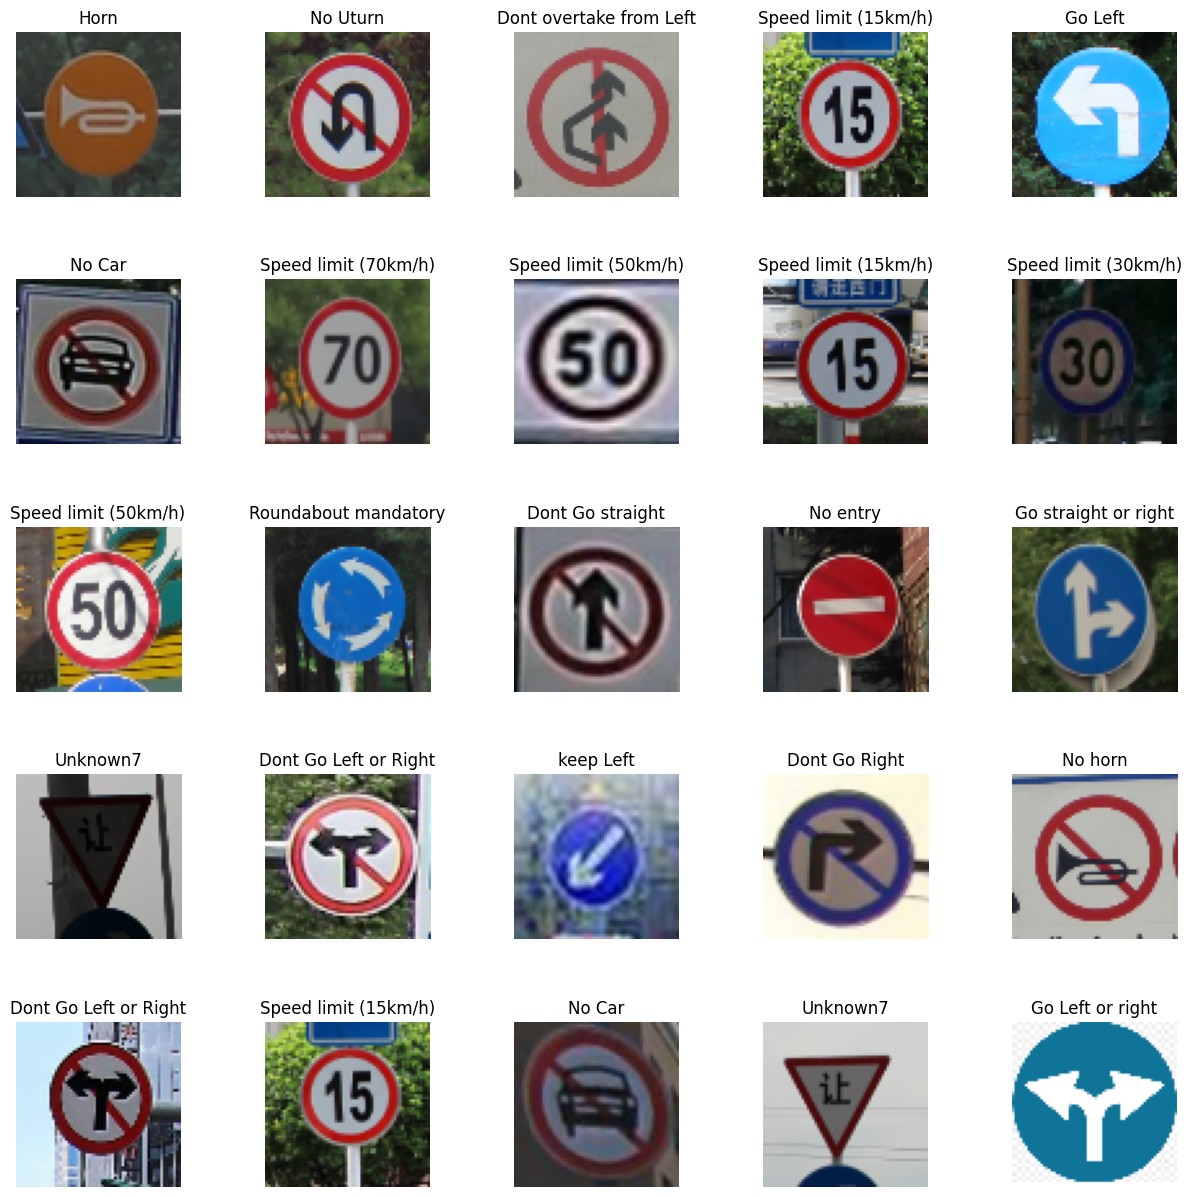

In [ ]:
plt.figure(figsize=(15, 15))

for images, labels in train_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()

    for i in range(min(25, images.shape[0])):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [ ]:
def process(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize
    image = data_augmentation(image)
    label = tf.one_hot(label, depth=num_classes)
    return image, label

# Apply to datasets
train_ds = train_ds.map(process).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(process).prefetch(tf.data.AUTOTUNE)


In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf
# Model
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),

    # First Conv Block
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Second Conv Block
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Third Conv Block
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2,2)),

    # Flatten Layer
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - accuracy: 0.0362 - loss: 3.4014 - val_accuracy: 0.0781 - val_loss: 3.2246
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 54s 618ms/step - accuracy: 0.0865 - loss: 3.1902 - val_accuracy: 0.1992 - val_loss: 2.8620
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 609ms/step - accuracy: 0.1717 - loss: 2.8324 - val_accuracy: 0.2948 - val_loss: 2.5302
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 655ms/step - accuracy: 0.2473 - loss: 2.5495 - val_accuracy: 0.3661 - val_loss: 2.1925
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 601ms/step - accuracy: 0.3466 - loss: 2.1903 - val_accuracy: 0.4293 - val_loss: 1.8957
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 610ms/step - accuracy: 0.3729 - loss: 2.0411 - val_accuracy: 0.5922 - val_loss: 1.4622
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 661ms/step - accuracy: 0.5370 - loss: 1.5060 - val_accuracy: 0.5814 - val_loss: 1.2211
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 663ms/step - accuracy: 0.5365 - loss: 1.3705 - val_accura

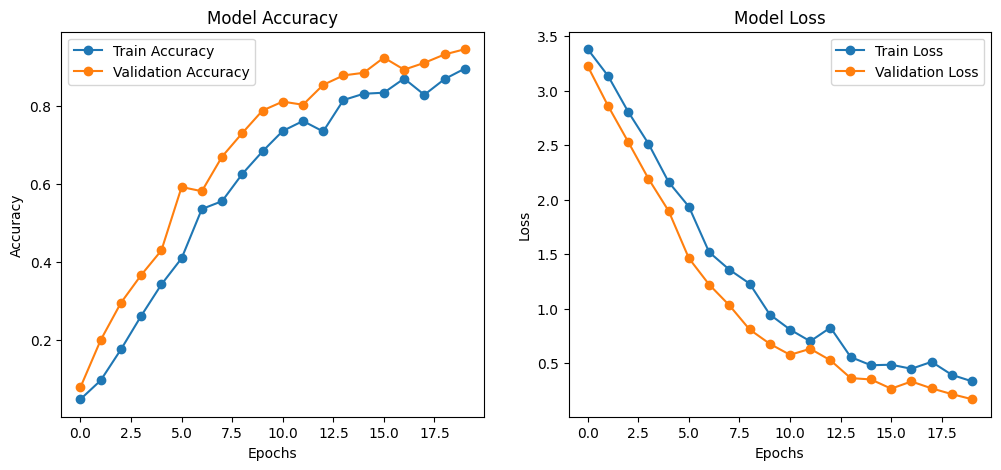

In [ ]:
# Plot Accuracy and Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

In [ ]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds)

# Print the results
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 39s 4s/step - accuracy: 0.5317 - loss: 2.8728
Test Loss: 3.6806344985961914
Test Accuracy: 0.4350877106189728


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
                          precision    recall  f1-score   support

     Speed limit (5km/h)       1.00      0.25      0.40         4
    Speed limit (15km/h)       0.86      1.00      0.92         6
        Dont Go straight       0.86      1.00      0.92        12
            Dont Go Left       0.70      0.64      0.67        22
   Dont Go Left or Right       0.00      0.00      0.00         9
           Dont Go Right       0.56      0.91      0.69        11
 Dont overtake from Left       1.00      0.50      0.67         2
                No Uturn       0.32      0.67      0.43        15
                  No Car       0.38      0.27      0.32

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


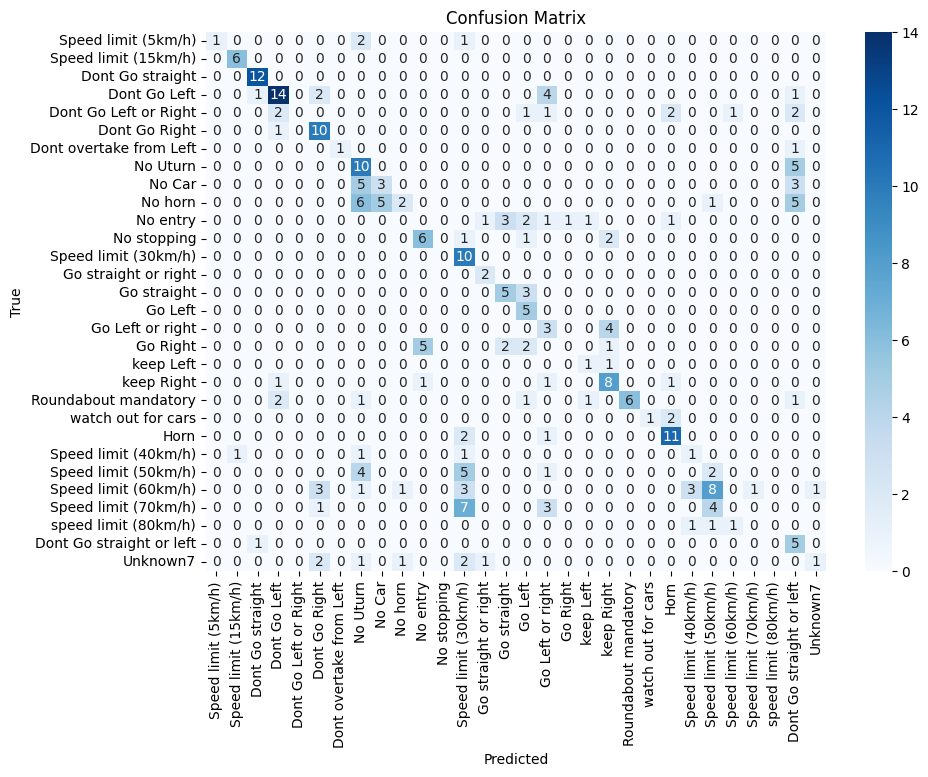

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get the true labels and predictions
true_labels = []
predictions = []

# Loop over batches in test dataset
for images, labels in test_ds:
    # If labels are one-hot encoded (categorical), convert them to integer labels
    true_labels.extend(np.argmax(labels.numpy(), axis=1))  # Convert to int labels

    # Get model predictions
    pred = model.predict(images)
    predicted_class = np.argmax(pred, axis=1)
    predictions.extend(predicted_class)

# Print the classification report
print(classification_report(true_labels, predictions, target_names=class_names))

# Plot confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def predict_image(image_path):
    # Load and preprocess image
    image = tf.keras.utils.load_img(image_path, target_size=(64, 64))
    input_arr = tf.keras.utils.img_to_array(image) / 255.0  # Normalize
    img_bat = tf.expand_dims(input_arr, axis=0)  # Add batch dimension

    # Predict
    predictions = model.predict(img_bat)
    predicted_class = np.argmax(predictions, axis=1)[0]
    predicted_label = class_names[predicted_class]

    # Plot image with prediction
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_label}", fontsize=14)
    plt.axis('off')
    plt.show()

    return predicted_label



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


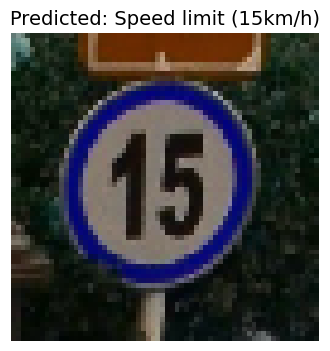

'Speed limit (15km/h)'

In [ ]:

predict_image("/content/drive/MyDrive/Road Sign Dataset/TEST/1/001_1_0003_1_j.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


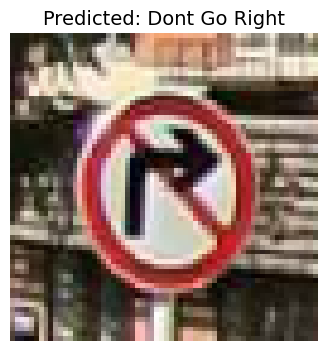

'Dont Go Right'

In [ ]:
predict_image("/content/drive/MyDrive/Road Sign Dataset/DATA/13/013_0022_j.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


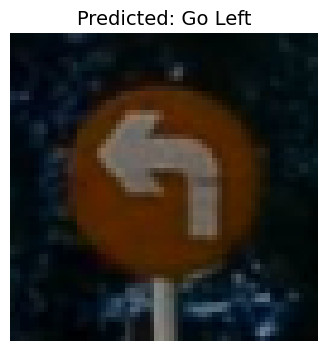

'Go Left'

In [ ]:
predict_image("/content/drive/MyDrive/Road Sign Dataset/TEST/22/022_0005_j.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


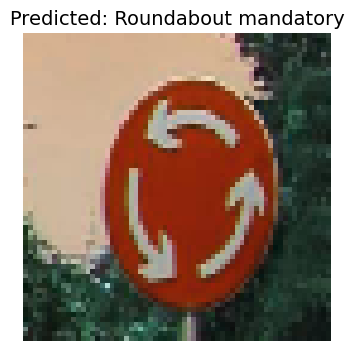

'Roundabout mandatory'

In [ ]:
predict_image("/content/drive/MyDrive/Road Sign Dataset/TEST/27/027_0006_j.png")

In [ ]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def load_and_preprocess(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=(64, 64))
    input_arr = tf.keras.utils.img_to_array(image) / 255.0
    img_bat = tf.expand_dims(input_arr, axis=0)
    return image, img_bat

def predict_images_in_folder(folder_path):
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    cols = 3
    rows = (len(image_files) + cols - 1) // cols

    plt.figure(figsize=(cols * 4, rows * 4))

    for idx, image_file in enumerate(image_files):
        image_path = os.path.join(folder_path, image_file)
        image, img_bat = load_and_preprocess(image_path)

        predictions = model.predict(img_bat)
        predicted_class = np.argmax(predictions, axis=1)[0]
        predicted_label = class_names[predicted_class]

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(image)
        plt.title(f"Predicted: {predicted_label}", fontsize=18)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


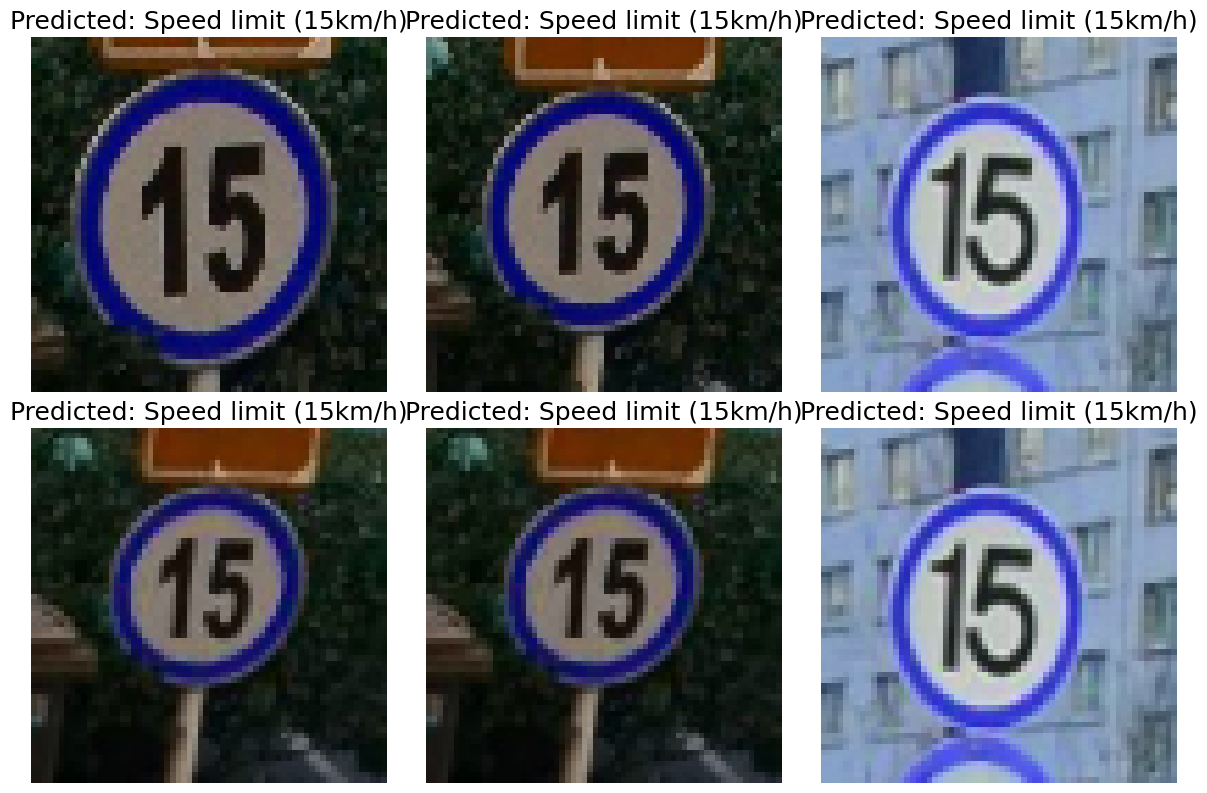

In [ ]:
folder_path = "/content/drive/MyDrive/Road Sign Dataset/TEST/1"
predict_images_in_folder(folder_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


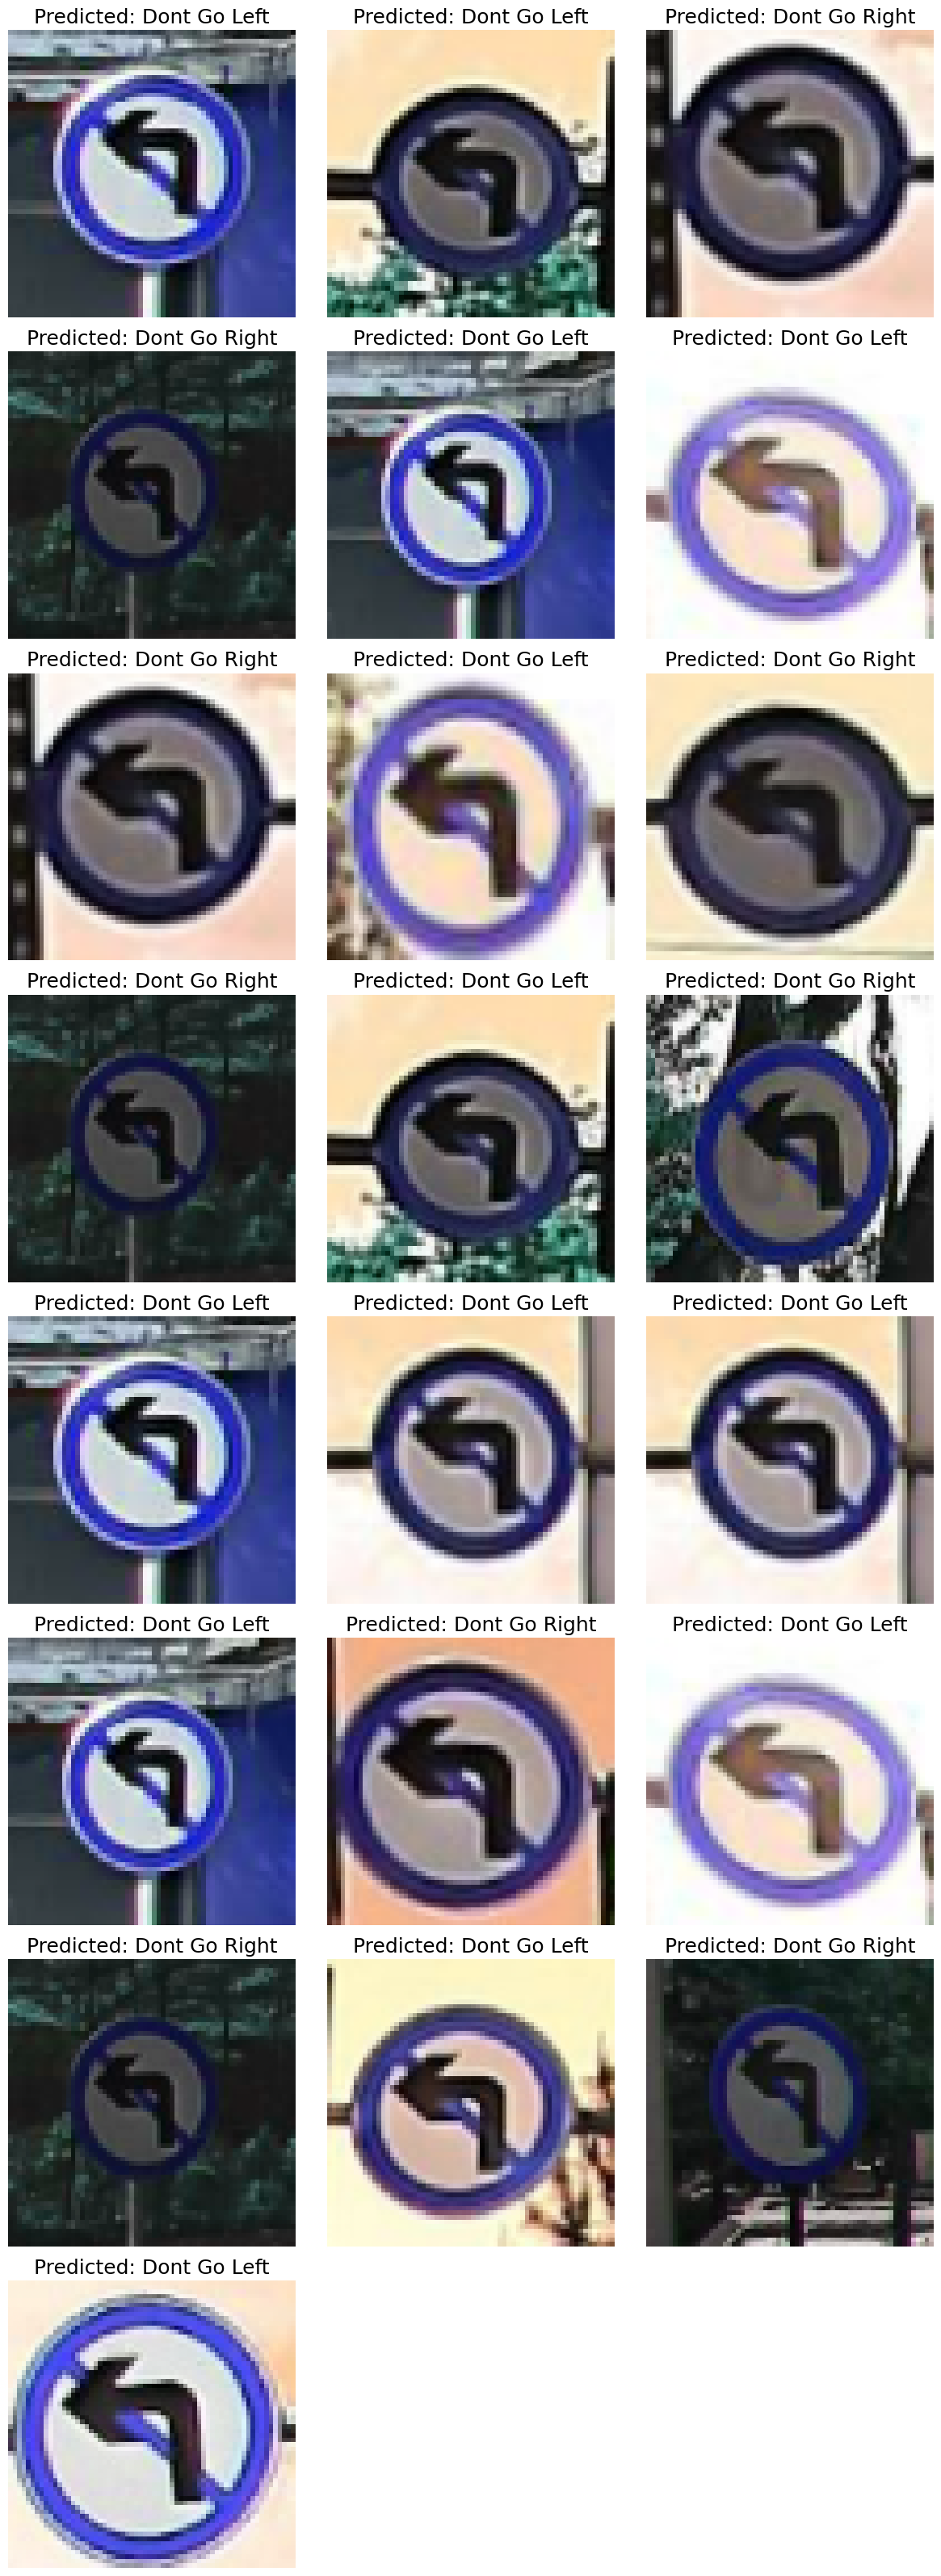

In [ ]:
folder_path = "/content/drive/MyDrive/Road Sign Dataset/TEST/11"
predict_images_in_folder(folder_path)

In [ ]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.3 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# Define the model building function for Keras Tuner
def build_model(hp):
    model = keras.Sequential()

    # First Conv layer
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_1', [32, 64, 128]),
        kernel_size=3,
        activation='relu',
        input_shape=(64, 64, 3)
    ))
    model.add(layers.MaxPooling2D())

    # Second Conv layer
    model.add(layers.Conv2D(
        filters=hp.Choice('filters_2', [64, 128, 192]),
        kernel_size=3,
        activation='relu'
    ))
    model.add(layers.MaxPooling2D())
    model.add(layers.Flatten())

    # Dense layer
    model.add(layers.Dense(
        units=hp.Choice('dense_units', [128, 256, 384, 512]),
        activation='relu'
    ))

    # Dropout
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))

    # Output layer
    model.add(layers.Dense(30, activation='softmax'))  # 30 classes

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='sparse_categorical_crossentropy',  # Correct loss
        metrics=['accuracy']
    )

    return model



In [ ]:
# Create a tuner instance
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='road_sign_tuning'
)

# Early stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Run the tuner
tuner.search(train_ds, validation_data=val_ds, epochs=10, callbacks=[early_stop])


Reloading Tuner from tuner_results/road_sign_tuning/tuner0.json


In [ ]:
# Get the best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:")
print(f"Filters 1: {best_hp.get('filters_1')}")
print(f"Filters 2: {best_hp.get('filters_2')}")
print(f"Dense units: {best_hp.get('dense_units')}")
print(f"Dropout: {best_hp.get('dropout')}")
print(f"Learning rate: {best_hp.get('learning_rate')}")

# Build the best model
best_model = tuner.hypermodel.build(best_hp)

# Train the best model fully
history = best_model.fit(train_ds, validation_data=val_ds, epochs=10)


Best Hyperparameters:
Filters 1: 32
Filters 2: 192
Dense units: 256
Dropout: 0.2
Learning rate: 0.001
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 709ms/step - accuracy: 0.1176 - loss: 223.0217 - val_accuracy: 0.6231 - val_loss: 1.5071
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 713ms/step - accuracy: 0.7055 - loss: 1.1925 - val_accuracy: 0.9556 - val_loss: 0.2534
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 683ms/step - accuracy: 0.9014 - loss: 0.3926 - val_accuracy: 0.9771 - val_loss: 0.0992
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 907ms/step - accuracy: 0.9238 - loss: 0.3351 - val_accuracy: 0.9690 - val_loss: 0.1641
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9624 - loss: 0.1570 - val_accuracy: 0.9879 - val_loss: 0.0544
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 33s 679ms/step - accuracy: 0.9665 - loss: 0.1164 - val_accuracy: 0.9960 - val_loss: 0.0139
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 784ms/step - accuracy: 0.9658 - loss: 0.1839 - val_accuracy: 0.9946 - val_loss: 0.0

In [ ]:
# Save in the .keras format (TensorFlow's recommended format)
best_model.save("/content/drive/MyDrive/RoadSign_Model_Best.keras")
print("✅ Model saved as RoadSign_Model_Best.keras")

# Save in the .h5 format (widely supported, including older tools)
best_model.save("/content/drive/MyDrive/RoadSign_Model_Best.h5")
print("✅ Model saved as RoadSign_Model_Best.h5")




✅ Model saved as RoadSign_Model_Best.keras
✅ Model saved as RoadSign_Model_Best.h5


In [ ]:
!pip install streamlit pyngrok -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
import pandas as pd

# 🔧 This must come before any other Streamlit command
st.set_page_config(page_title="Road Sign Classifier", layout="centered")

# Load trained model (.h5 or .keras)
@st.cache_resource
def load_model():
    model_path = "/content/drive/MyDrive/RoadSign_Model_Best.h5"
    return tf.keras.models.load_model(model_path)

# Load labels
@st.cache_data
def load_labels():
    labels_path = "/content/drive/MyDrive/Road Sign Dataset/labels.csv"
    df = pd.read_csv(labels_path)
    df["ClassId"] = df["ClassId"].astype(str)
    return df.set_index("ClassId")["Name"].to_dict()

model = load_model()
class_id_to_name = load_labels()

# Preprocessing function
def preprocess_image(image: Image.Image):
    image = image.resize((64, 64))
    image_array = np.array(image) / 255.0
    if image_array.shape[-1] == 4:  # Handle RGBA images
        image_array = image_array[..., :3]
    image_array = np.expand_dims(image_array, axis=0)
    return image_array

# Streamlit UI
st.title("🚦 Road Sign Classification")
st.markdown("Upload an image of a road sign to classify it using a trained deep learning model.")

uploaded_file = st.file_uploader("📁 Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="🖼 Uploaded Image", use_column_width=True)

    if st.button("🔍 Classify"):
        with st.spinner("🔎 Predicting the road sign..."):
            # Preprocess image
            image_array = preprocess_image(image)

            # Make prediction
            predictions = model.predict(image_array)[0]
            predicted_idx = np.argmax(predictions)
            confidence = predictions[predicted_idx] * 100
            predicted_class = str(predicted_idx)
            predicted_name = class_id_to_name.get(predicted_class, "Unknown")

        # Display top prediction
        st.markdown("---")
        st.success(f"### 🏷 Predicted Road Sign: **{predicted_name}**")
        st.info(f"🔢 Class ID: `{predicted_class}`")
        st.info(f"💡 Confidence Score: **{confidence:.2f}%**")

        # Confidence Warning
        if confidence < 50:
            st.warning("⚠️ Confidence is low. The model might be unsure about this prediction.")

        # Show Top-3 Predictions
        top_3_indices = predictions.argsort()[-3:][::-1]
        st.markdown("#### 📊 Top 3 Predictions:")
        for idx in top_3_indices:
            label = class_id_to_name.get(str(idx), "Unknown")
            prob = predictions[idx] * 100
            st.write(f"🔸 **{label}** — `{prob:.2f}%`")



Overwriting app.py


In [ ]:

!ngrok authtoken 2ussbycOHN7zsRy2Sh7mIMLIDAU_4bVKfp5B6mS72dBtEBp5V
!streamlit run app.py &>/dev/null&

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print("Streamlit App is running at:", public_url)

Streamlit App is running at: NgrokTunnel: "https://b097-34-48-121-127.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!pkill streamlit
!pkill ngrok